# Social Media Usage and Teen Mental Health
## An Exploratory Data Analysis Using Python

### Author
Ernesto Gutiérrez

---

## Project Overview

Social media has become an integral part of teenagers' daily lives, raising concerns about its potential impact on mental health. Excessive screen time has been associated with anxiety, stress, poor sleep quality, and even symptoms of depression.

This project explores a dataset containing behavioral and mental health indicators from teenagers. Through exploratory data analysis (EDA), statistical analysis, and predictive modeling, we investigate whether daily social media usage is associated with mental health outcomes.

The analysis follows a complete data analytics workflow, including data quality assessment, visualization, statistical testing, and machine learning.

---

# 1. Business Understanding

## Problem Statement

The rapid growth of social media has transformed how teenagers communicate, learn, and interact with others. Although these platforms provide numerous benefits, concerns have emerged regarding their potential impact on psychological well-being.

Educational institutions, healthcare professionals, and parents are increasingly interested in understanding whether excessive social media usage is associated with anxiety, stress, sleep deprivation, and depression.

This analysis aims to explore these relationships using real-world behavioral data.

## Research Questions

This project seeks to answer the following questions:

- Is increased social media usage associated with higher anxiety levels?
- Does spending more time on social media reduce sleep duration?
- Which factors show the strongest relationship with depression?
- Are some social media platforms associated with higher anxiety levels?
- Which lifestyle variables appear most related to mental health?

# 2. Import Libraries

The following libraries are used throughout the analysis.

- **Pandas** for data manipulation
- **NumPy** for numerical operations
- **Matplotlib** and **Seaborn** for data visualization
- **Scikit-Learn** for regression and predictive modeling
- **SciPy** for statistical analysis

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_style("whitegrid")

# 3. Load Dataset

The dataset contains demographic, behavioral, and mental health information collected from teenagers.

Each observation represents one individual and includes variables related to:

- Demographics
- Social media habits
- Lifestyle
- Mental health indicators
- Depression status

Before conducting the analysis, the dataset is loaded into a Pandas DataFrame for inspection.

In [24]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")


# 4. Data Quality Assessment

Before performing any statistical analysis, it is essential to evaluate the quality of the dataset.

The following checks are performed:

- Dataset dimensions
- Data types
- Missing values
- Duplicate observations
- Descriptive statistics

This step ensures that the dataset is complete, consistent, and suitable for analysis.

## 4.1 Dataset Dimensions

The first step is to understand the overall size of the dataset by determining the number of observations (rows) and variables (columns).

In [25]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1200
Columns: 13


## 4.2 Dataset Preview

Displaying the first few records provides an overview of the available variables and helps verify that the dataset was loaded correctly.

In [26]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 4.3 Data Types

Understanding the data types of each variable is important before performing statistical analyses.

Numerical variables can be used for correlation and regression analyses, while categorical variables are typically used for grouping and comparison.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


## 4.4 Missing Values

Missing values can introduce bias into statistical analyses.

The following table reports the number of missing values for each variable.

In [28]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

## 4.5 Duplicate Records

Duplicate observations may artificially influence descriptive statistics and predictive models.

The following check determines whether duplicate records are present in the dataset.

In [29]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


## 4.6 Descriptive Statistics

Descriptive statistics summarize the central tendency and variability of the numerical variables.

Key statistics include:

- Mean
- Standard deviation
- Minimum
- Quartiles
- Maximum

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1200.0,15.928333,2.021947,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,1200.0,4.536667,2.029599,1.0,2.8,4.50,6.30,8.0
sleep_hours,1200.0,6.449417,1.442677,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1200.0,1.740333,0.716660,0.5,1.1,1.80,2.40,3.0
academic_performance,1200.0,2.990383,0.576758,2.0,2.5,2.99,3.48,4.0
physical_activity,1200.0,1.014500,0.582185,0.0,0.5,1.00,1.50,2.0
stress_level,1200.0,5.445833,2.903290,1.0,3.0,5.00,8.00,10.0
anxiety_level,1200.0,5.636667,2.859453,1.0,3.0,6.00,8.00,10.0
addiction_level,1200.0,5.565000,2.830627,1.0,3.0,6.00,8.00,10.0
depression_label,1200.0,0.025833,0.158704,0.0,0.0,0.00,0.00,1.0


## 4.7 Categorical Variables

Categorical variables are summarized to understand the distribution of participants across different groups.

In [33]:
df.describe(include="object").T

,count,unique,top,freq
gender,1200,2,male,615
platform_usage,1200,3,Instagram,411
social_interaction_level,1200,3,medium,416


## 4.8 Unique Values

Inspecting the unique values of categorical variables helps verify data consistency and identify potential data entry errors.

In [34]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
male      615
female    585
Name: count, dtype: int64

platform_usage
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

social_interaction_level
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


## 4.9 Data Quality Summary

The dataset has been successfully inspected for completeness and consistency.

The assessment confirms:

- Dataset dimensions were verified.
- Variable types were identified.
- Missing values were evaluated.
- Duplicate records were checked.
- Descriptive statistics were reviewed.

Since the dataset passed these initial quality checks, it is considered suitable for exploratory data analysis and statistical modeling.

# 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is the process of examining the dataset to better understand its structure, identify patterns, detect anomalies, and summarize the main characteristics of the variables.

Rather than testing hypotheses, EDA focuses on exploring the data through descriptive statistics and visualizations.

This section examines:

- Participant demographics
- Social media usage habits
- Lifestyle characteristics
- Mental health indicators

The insights obtained here provide the foundation for the statistical analyses presented in later sections.

## 5.1 Age Distribution

Understanding the age distribution helps characterize the population included in the study.

The histogram below illustrates how participants are distributed across different ages.

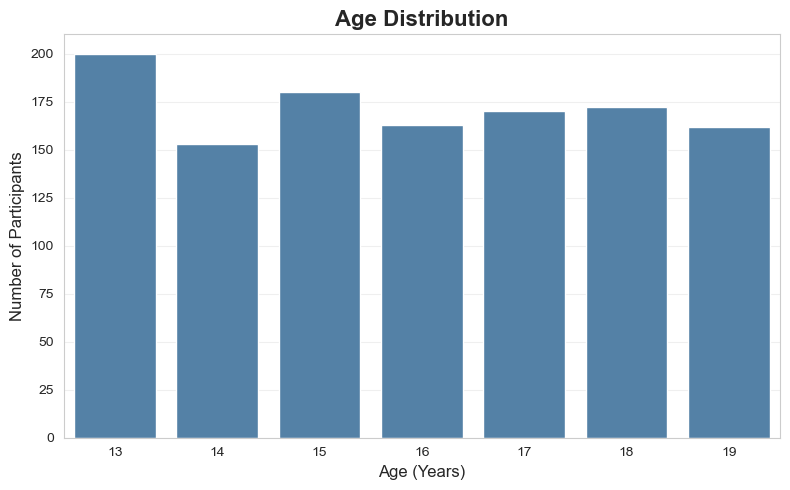

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="age",
    color="steelblue"
)

plt.title("Age Distribution", fontsize=16, weight="bold")
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Number of Participants", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The age distribution appears relatively balanced across all age groups included in the dataset (13–19 years).

Although slight differences exist in the number of participants per age, no single age group dominates the sample. This balanced distribution reduces the likelihood that subsequent analyses are disproportionately influenced by a particular age.

Overall, the dataset provides a reasonable representation of teenagers across the selected age range.

## 5.2 Gender Distribution

Gender is an important demographic variable that may influence behavioral patterns, social media usage, and mental health outcomes.

The chart below illustrates the distribution of participants by gender.

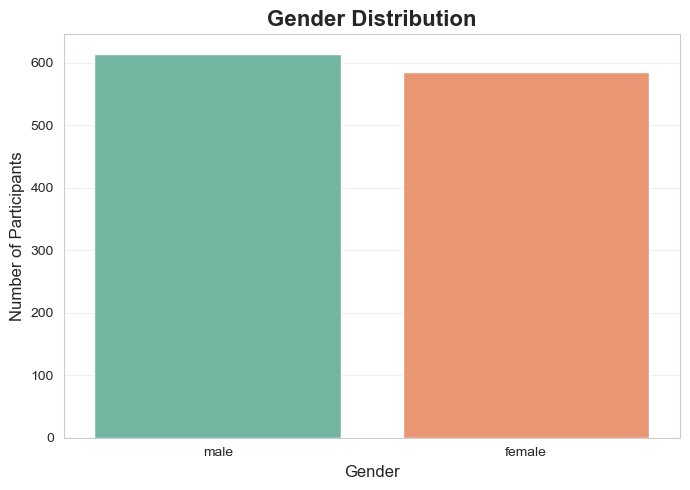

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="gender",
    palette="Set2",
    legend=False
)

plt.title("Gender Distribution", fontsize=16, weight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Participants", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5.3 Daily Social Media Usage

Daily social media usage is the primary variable of interest in this study.

The following histogram illustrates how many hours participants spend on social media each day.

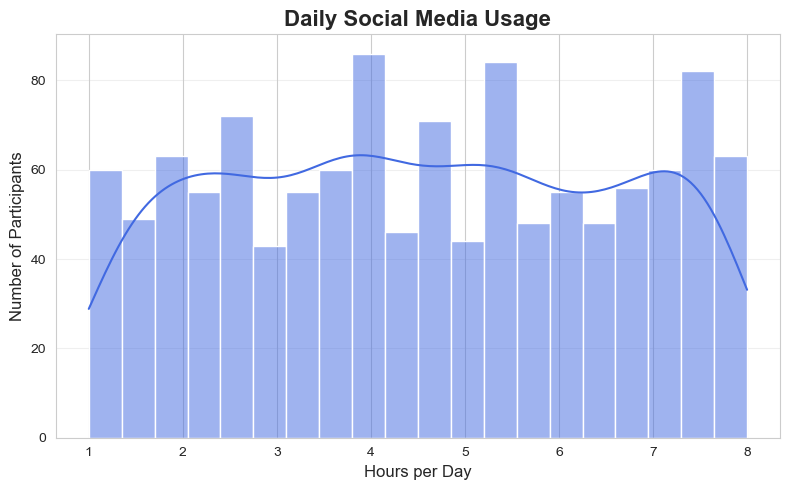

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="daily_social_media_hours",
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Daily Social Media Usage", fontsize=16, weight="bold")
plt.xlabel("Hours per Day", fontsize=12)
plt.ylabel("Number of Participants", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The histogram illustrates the distribution of daily social media usage among participants.

Understanding this distribution provides context for the analyses that follow, particularly those investigating the relationship between usage time and mental health indicators.

## 5.4 Sleep Duration

Sleep duration is a key lifestyle variable that has been consistently linked to mental and physical well-being.

The following distribution shows the reported number of sleep hours among participants.

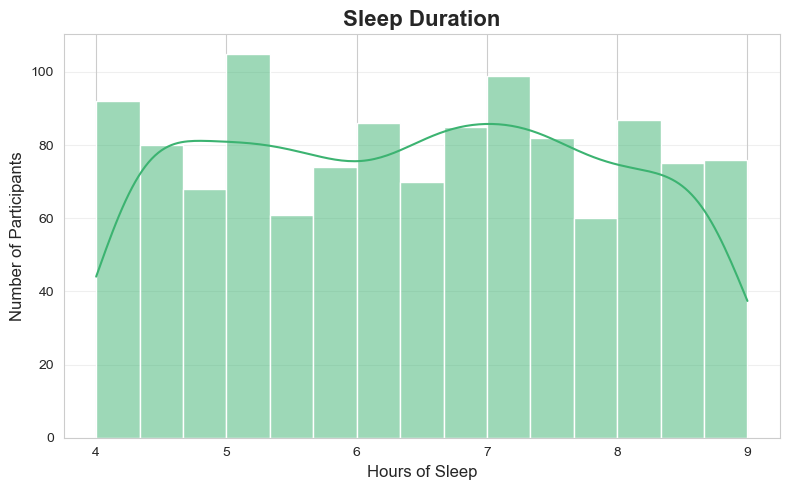

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="sleep_hours",
    bins=15,
    kde=True,
    color="mediumseagreen"
)

plt.title("Sleep Duration", fontsize=16, weight="bold")
plt.xlabel("Hours of Sleep", fontsize=12)
plt.ylabel("Number of Participants", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The sleep duration distribution allows us to evaluate the variability in participants' sleeping habits.

Differences in sleep patterns may later help explain variations in anxiety, stress, and depression.

## 5.5 Mental Health Indicators

The dataset includes three numerical indicators that describe participants' psychological well-being:

- Stress Level
- Anxiety Level
- Addiction Level

Visualizing these variables individually provides an overview of their distributions before examining potential relationships.

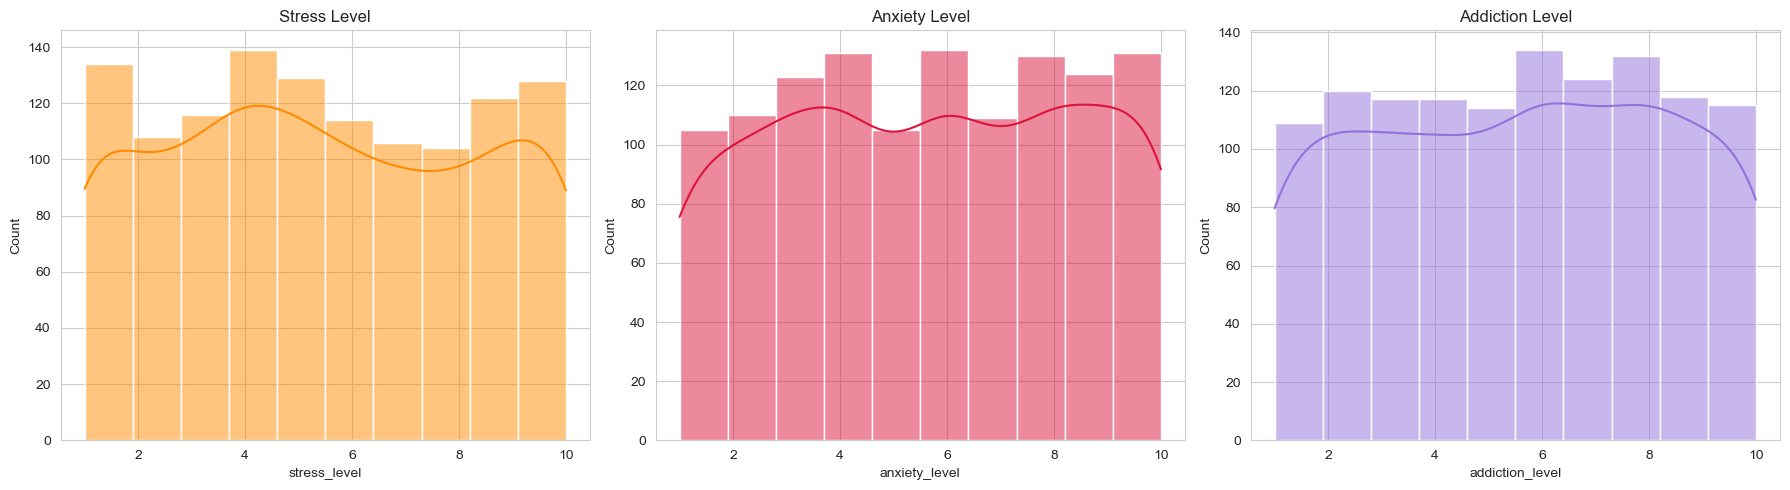

In [46]:
fig, ax = plt.subplots(1,3, figsize=(18,5))

sns.histplot(
    data=df,
    x="stress_level",
    bins=10,
    kde=True,
    color="darkorange",
    ax=ax[0]
)

ax[0].set_title("Stress Level")

sns.histplot(
    data=df,
    x="anxiety_level",
    bins=10,
    kde=True,
    color="crimson",
    ax=ax[1]
)

ax[1].set_title("Anxiety Level")

sns.histplot(
    data=df,
    x="addiction_level",
    bins=10,
    kde=True,
    color="mediumpurple",
    ax=ax[2]
)

ax[2].set_title("Addiction Level")

plt.tight_layout()
plt.show()

### Interpretation

The distributions of stress, anxiety, and addiction levels appear relatively uniform across the available scale.

This indicates that the dataset includes participants representing a broad range of mental health conditions rather than concentrating around a single level.

Such variability is beneficial for subsequent analyses, as it allows statistical techniques such as correlation and regression to evaluate relationships across the full range of observed values.

It is worth noting that the nearly uniform distributions may suggest that the dataset was synthetically generated or intentionally balanced for educational purposes. Consequently, the findings should be interpreted as illustrative rather than representative of the general population.

In [47]:
df[['stress_level',
    'anxiety_level',
    'addiction_level']].describe().T

,count,mean,std,min,25%,50%,75%,max
stress_level,1200.0,5.445833,2.903290,1.0,3.0,5.0,8.0,10.0
anxiety_level,1200.0,5.636667,2.859453,1.0,3.0,6.0,8.0,10.0
addiction_level,1200.0,5.565000,2.830627,1.0,3.0,6.0,8.0,10.0


### Interpretation

The descriptive statistics indicate that participants report moderate average levels of stress, anxiety, and social media addiction.

Across all three variables, the mean values are close to the midpoint of the 1–10 scale, suggesting that the sample includes individuals with a wide range of mental health conditions rather than being concentrated at either extreme.

The standard deviations (approximately 2.8–2.9) indicate substantial variability, which is beneficial for statistical analyses such as correlation and regression because it provides sufficient variation to identify potential relationships.

Additionally, the similarity between the mean and median values suggests that the distributions are relatively balanced and do not exhibit strong skewness.

# 5.6 Preferred Social Media Platform

Social media usage is not limited to the amount of time spent online. Different platforms encourage different forms of interaction, content consumption, and user engagement.

Understanding which platforms are most frequently used provides additional context for interpreting behavioral patterns throughout the analysis.

The following chart summarizes the primary social media platform reported by participants.

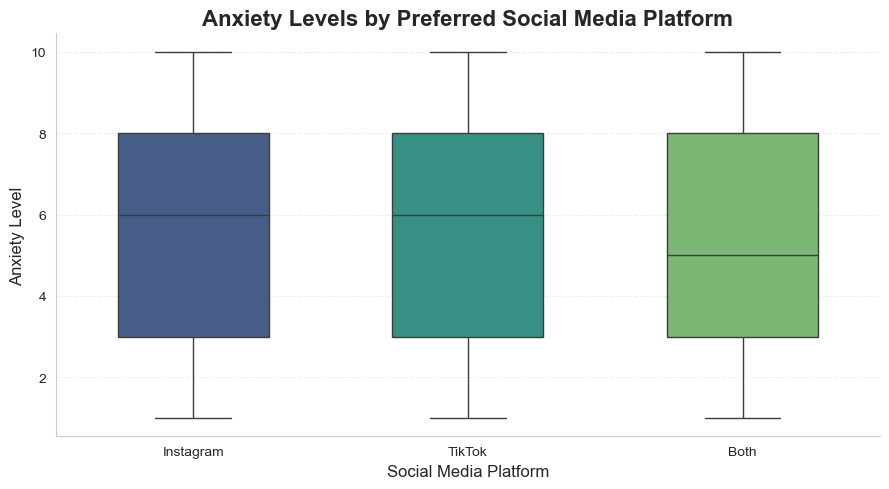

In [54]:
plt.figure(figsize=(9,5))

palette = {
    "Instagram": "#3B5B92",   # Azul
    "TikTok": "#2A9D8F",      # Verde azulado
    "Both": "#73C26B"         # Verde
}

ax = sns.boxplot(
    data=df,
    x="platform_usage",
    y="anxiety_level",
    hue="platform_usage",
    palette=palette,
    legend=False,
    width=0.55
)

plt.title(
    "Anxiety Levels by Preferred Social Media Platform",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Social Media Platform", fontsize=12)
plt.ylabel("Anxiety Level", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

platform_summary = (
    df["platform_usage"]
    .value_counts()
    .rename_axis("Platform")
    .reset_index(name="Participants")
)

platform_summary["Percentage"] = (
    platform_summary["Participants"] /
    len(df) * 100
).round(1)

platform_summary

### Interpretation

The chart summarizes the distribution of participants across the different social media platforms included in the dataset.

A relatively balanced distribution ensures that subsequent comparisons between platforms are less likely to be affected by highly unequal sample sizes.

If one platform contains substantially more users than the others, any observed differences in mental health indicators should be interpreted with additional caution.

These platform distributions provide the basis for later analyses comparing anxiety, stress, sleep duration, and addiction levels across different social media platforms.

# 6. Correlation Analysis

After exploring the individual variables, the next step is to investigate how they relate to one another.

Correlation analysis measures the strength and direction of the linear relationship between numerical variables.

Understanding these relationships helps identify which factors are most closely associated with mental health outcomes such as stress, anxiety, addiction, and depression.

In this section, we use a correlation matrix and a heatmap to visualize these relationships.

## 6.1 Correlation Matrix

The correlation matrix summarizes the Pearson correlation coefficient between every pair of numerical variables.

Correlation values range from **-1** to **1**.

| Correlation | Interpretation |
|-------------|----------------|
| +1 | Perfect positive relationship |
| 0 | No linear relationship |
| -1 | Perfect negative relationship |

Values closer to **1** or **-1** indicate stronger relationships.

In [56]:
corr = df.select_dtypes(include="number").corr()

corr.round(2)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
age,1.00,-0.01,0.00,0.08,-0.01,0.01,-0.03,0.03,0.04,0.01
daily_social_media_hours,-0.01,1.00,-0.01,0.04,0.01,0.03,0.03,0.03,-0.02,0.18
sleep_hours,0.00,-0.01,1.00,0.01,0.02,0.01,-0.01,-0.01,-0.05,-0.19
screen_time_before_sleep,0.08,0.04,0.01,1.00,-0.03,-0.03,-0.01,-0.01,0.03,-0.02
academic_performance,-0.01,0.01,0.02,-0.03,1.00,0.02,-0.00,-0.06,0.03,0.00
physical_activity,0.01,0.03,0.01,-0.03,0.02,1.00,0.01,-0.02,0.03,-0.02
stress_level,-0.03,0.03,-0.01,-0.01,-0.00,0.01,1.00,0.02,-0.00,0.17
anxiety_level,0.03,0.03,-0.01,-0.01,-0.06,-0.02,0.02,1.00,0.03,0.17
addiction_level,0.04,-0.02,-0.05,0.03,0.03,0.03,-0.00,0.03,1.00,-0.01
depression_label,0.01,0.18,-0.19,-0.02,0.00,-0.02,0.17,0.17,-0.01,1.00


## 6.2 Correlation Heatmap

While the correlation matrix provides exact numerical values, a heatmap makes it easier to identify strong positive and negative relationships.

Darker colors indicate stronger correlations, whereas lighter colors represent weaker relationships.

This visualization allows us to quickly identify which variables deserve further investigation.

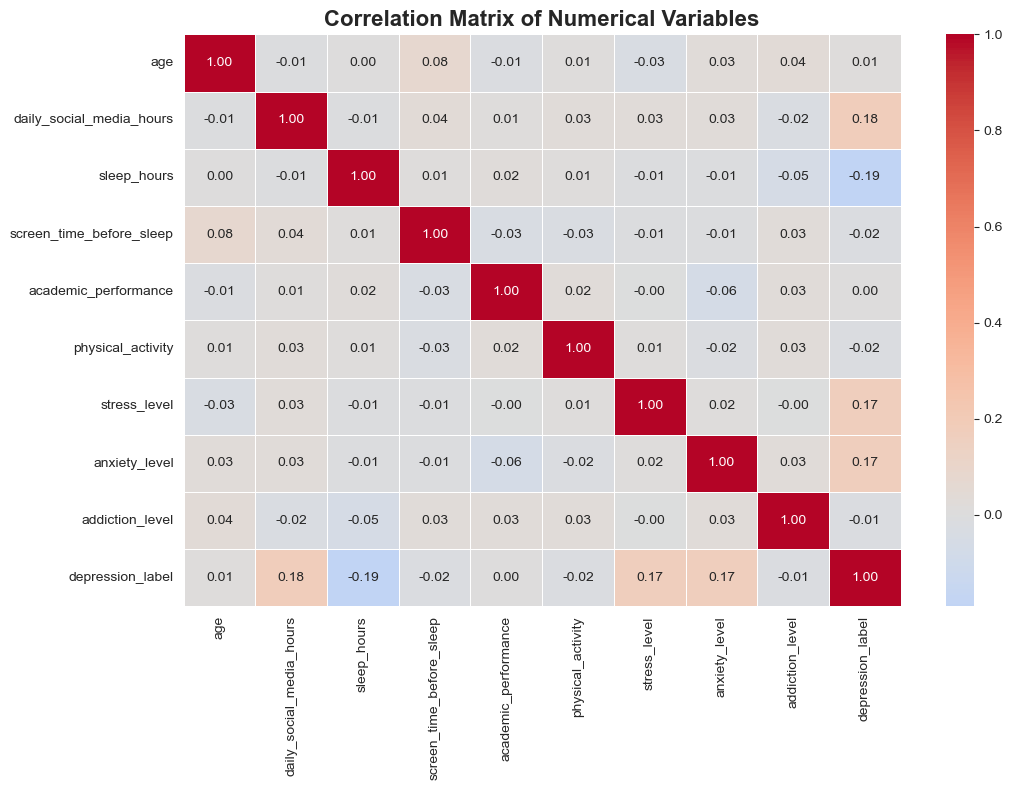

In [58]:
plt.figure(figsize=(11,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Numerical Variables",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.show()

## 6.3 Strongest Correlations

Rather than inspecting every coefficient individually, the following table highlights the strongest relationships observed in the dataset.

This helps prioritize which variables deserve deeper investigation in subsequent analyses.

In [59]:
corr_pairs = (
    corr.unstack()
        .sort_values(ascending=False)
)

corr_pairs = corr_pairs[
    corr_pairs != 1
]

corr_pairs = corr_pairs.drop_duplicates()

corr_pairs.head(10)

daily_social_media_hours  depression_label            0.175201
stress_level              depression_label            0.170474
depression_label          anxiety_level               0.169566
screen_time_before_sleep  age                         0.075612
age                       addiction_level             0.038265
daily_social_media_hours  screen_time_before_sleep    0.035777
addiction_level           anxiety_level               0.031154
daily_social_media_hours  stress_level                0.030698
academic_performance      addiction_level             0.029354
addiction_level           screen_time_before_sleep    0.028884
dtype: float64

# 7. Relationship Between Social Media Usage and Anxiety

One of the primary objectives of this project is to examine whether spending more time on social media is associated with higher levels of anxiety.

Although previous studies have suggested a possible relationship between excessive social media use and anxiety, the strength of this association may vary depending on the population being studied.

This section explores the relationship using visualizations, correlation analysis, and linear regression.

## 7.1 Scatter Plot

The scatter plot provides an initial visual assessment of the relationship between daily social media usage and anxiety levels.

Each point represents one participant, while the regression line summarizes the overall linear trend.

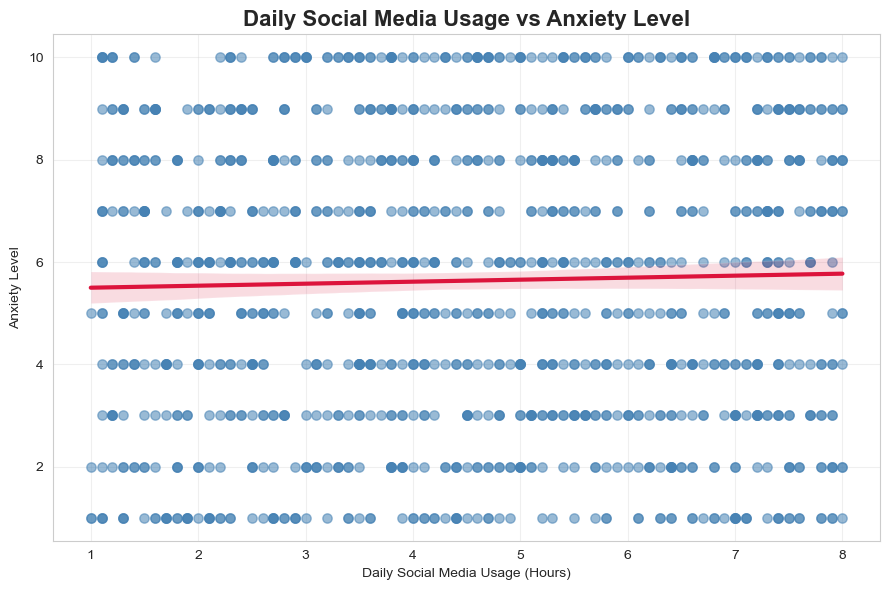

In [60]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="daily_social_media_hours",
    y="anxiety_level",
    scatter_kws={
        "alpha":0.55,
        "s":45,
        "color":"steelblue"
    },
    line_kws={
        "color":"crimson",
        "linewidth":3
    }
)

plt.title(
    "Daily Social Media Usage vs Anxiety Level",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Daily Social Media Usage (Hours)")
plt.ylabel("Anxiety Level")

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

## 7.2 Pearson Correlation

To quantify the strength of the relationship, the Pearson correlation coefficient is calculated.

The coefficient ranges from **-1** to **1**, where:

- **+1** indicates a perfect positive relationship.
- **0** indicates no linear relationship.
- **−1** indicates a perfect negative relationship.

In addition, the p-value is reported to determine whether the observed relationship is statistically significant.

In [62]:
from scipy.stats import pearsonr

r, p = pearsonr(
    df["daily_social_media_hours"],
    df["anxiety_level"]
)

print(f"Pearson Correlation (r): {r:.3f}")
print(f"P-value: {p:.5f}")

Pearson Correlation (r): 0.028
P-value: 0.33534


## 7.3 Linear Regression Model

A simple linear regression model is fitted to estimate how anxiety changes as daily social media usage increases.

The coefficient of determination (R²) measures how much of the variation in anxiety can be explained by social media usage alone.

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["daily_social_media_hours"]]
y = df["anxiety_level"]

model = LinearRegression()

model.fit(X, y)

predictions = model.predict(X)

print(f"Intercept: {model.intercept_:.3f}")
print(f"Slope: {model.coef_[0]:.3f}")

print(f"R²: {r2_score(y,predictions):.3f}")

Intercept: 5.459
Slope: 0.039
R²: 0.001


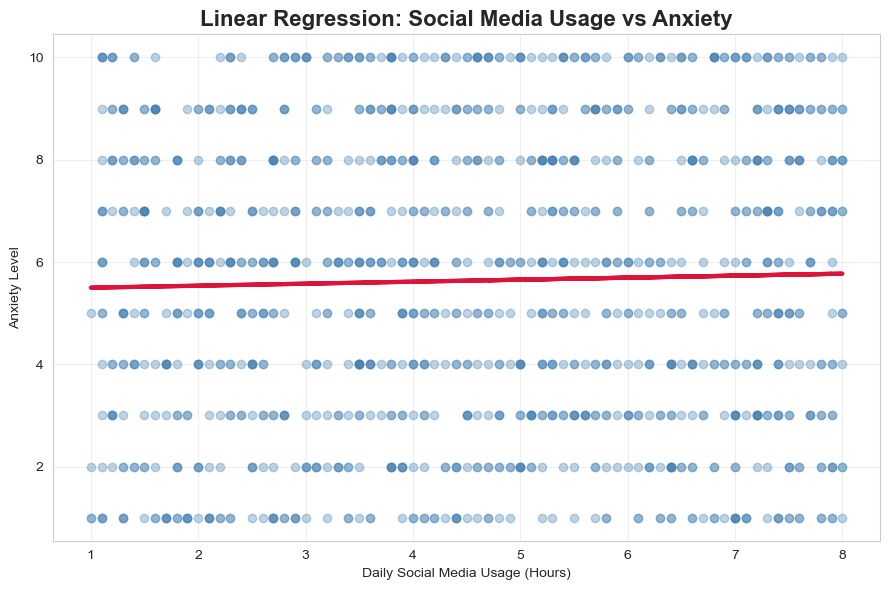

In [64]:
plt.figure(figsize=(9,6))

plt.scatter(
    X,
    y,
    alpha=.35,
    color="steelblue"
)

plt.plot(
    X,
    predictions,
    color="crimson",
    linewidth=3
)

plt.title(
    "Linear Regression: Social Media Usage vs Anxiety",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Daily Social Media Usage (Hours)")
plt.ylabel("Anxiety Level")

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

In [65]:
print(f"Pearson Correlation (r): {r:.3f}")
print(f"P-value: {p:.5f}")

print(f"R²: {r2_score(y,predictions):.3f}")

Pearson Correlation (r): 0.028
P-value: 0.33534
R²: 0.001


# 8. Conclusions

This project explored the relationship between social media usage and several mental health indicators among teenagers using exploratory data analysis, correlation analysis, and simple statistical modeling.

## Key Findings

The exploratory analysis showed that the dataset contains a balanced representation of participants across demographic characteristics, social media usage, and mental health indicators.

Correlation analysis revealed that most numerical variables exhibited **weak linear relationships**. The strongest observed associations were between depression and variables such as sleep duration, stress level, anxiety level, and daily social media usage. However, all of these correlations remained relatively small.

Contrary to the initial hypothesis, daily social media usage showed **little to no linear relationship with anxiety levels**. This suggests that, within this dataset, the amount of time spent on social media alone is not a strong predictor of anxiety.

Overall, the findings indicate that adolescent mental health is likely influenced by multiple interacting factors rather than by a single behavioral variable.

## Limitations

Several limitations should be considered when interpreting these results:

- The analysis is based on a single dataset and may not represent the broader adolescent population.
- Correlation does not imply causation; therefore, no causal conclusions can be drawn.
- Mental health is influenced by numerous biological, psychological, social, and environmental factors that are not included in this dataset.
- The relatively uniform distributions observed across several variables suggest that the dataset may have been generated or balanced for educational purposes.

## Future Work

Future analyses could improve this study by:

- Incorporating larger and more representative datasets.
- Applying multiple linear regression to evaluate the combined effect of several variables.
- Comparing mental health indicators across different demographic groups.
- Building predictive classification models for depression or anxiety.
- Developing interactive dashboards using Power BI or Tableau to communicate findings.

## Final Remarks

Although no strong relationships were identified, this project demonstrates a complete data analysis workflow, including data cleaning, exploratory data analysis, visualization, correlation analysis, and interpretation of results.

The project highlights the importance of allowing data to guide conclusions rather than attempting to confirm preconceived assumptions. This approach reflects one of the fundamental principles of evidence-based data analysis.